# Redundancy in hidden Transformer layers - vision model similarity

*Commands to reproduce audio model results regarding CKA and cosine similarity of intermediate layers:*

```
TODO: add commands
```

In [1]:
from pathlib import Path

import torch
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
plt.style.use('ggplot')

cmaps = {
    'cosine': 'RdGy',
    'cka': 'BrBG',
    'jacobian': 'RdBu',
}

EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments")

In [2]:
def plot_similarity_matrices(experiments, types=['cosine', 'cka']):
    for exp_name, exp_path in experiments.items():
        results = torch.load(exp_path)
        
        if 'cosine' in types:
            sim_type = 'cosine'
            similarities = results[f'all-{sim_type}-similarities']
            fig, axs = plt.subplots(2,2, figsize=(10, 10))
            for j, _loc in enumerate(['within', 'between']):
                sims = torch.stack([sim[_loc] for sim in similarities])
                _mean, _std = sims.mean(dim=0), sims.std(dim=0)

                for i, _sims in enumerate([_mean, _std]):
                    norm = TwoSlopeNorm(vmin=min(_sims.min(), -1e-7), vcenter=0., vmax=max(_sims.max(), 1e-7))
                    cbar = plt.cm.ScalarMappable(norm=norm, cmap=cmaps[sim_type])
                    axs[i,j].imshow(_sims, cmap=cmaps[sim_type], norm=norm)
                    axs[i,j].grid(False)
                    axs[i,j].set_title(f'{_loc.capitalize()} blocks')
                    fig.colorbar(cbar, ax=axs[i,j], fraction=0.04)

            fig.suptitle(f"{exp_name.capitalize()}\nCosine similarity", fontsize=18)
            plt.tight_layout()
            plt.show()

        if 'cka' in types:
            sim_type = 'cka'
            similarities = results[f'all-{sim_type}-similarities']
            _mean, _std = torch.stack(similarities).mean(dim=0), torch.stack(similarities).std(dim=0)

            fig, axs = plt.subplots(2,2, figsize=(10, 10))
            for i, _sims in enumerate([_mean, _std]):
                for j, _loc in enumerate(['within', 'between']):
                    norm = TwoSlopeNorm(vmin=min(_sims[j::2, j::2].min(), -1e-7), vcenter=0., vmax=max(_sims[j::2, j::2].max(), 1e-7))
                    cbar = plt.cm.ScalarMappable(norm=norm, cmap=cmaps[sim_type])
                    axs[i,j].imshow(_sims[j::2, j::2], cmap=cmaps[sim_type], norm=norm)
                    axs[i,j].grid(False)
                    axs[i,j].set_title(f'{_loc.capitalize()} blocks')
                    fig.colorbar(cbar, ax=axs[i,j], fraction=0.04)

            fig.suptitle(f"{exp_name.capitalize()}\n{sim_type.capitalize()} similarity", fontsize=18)
            plt.tight_layout()
            plt.show()

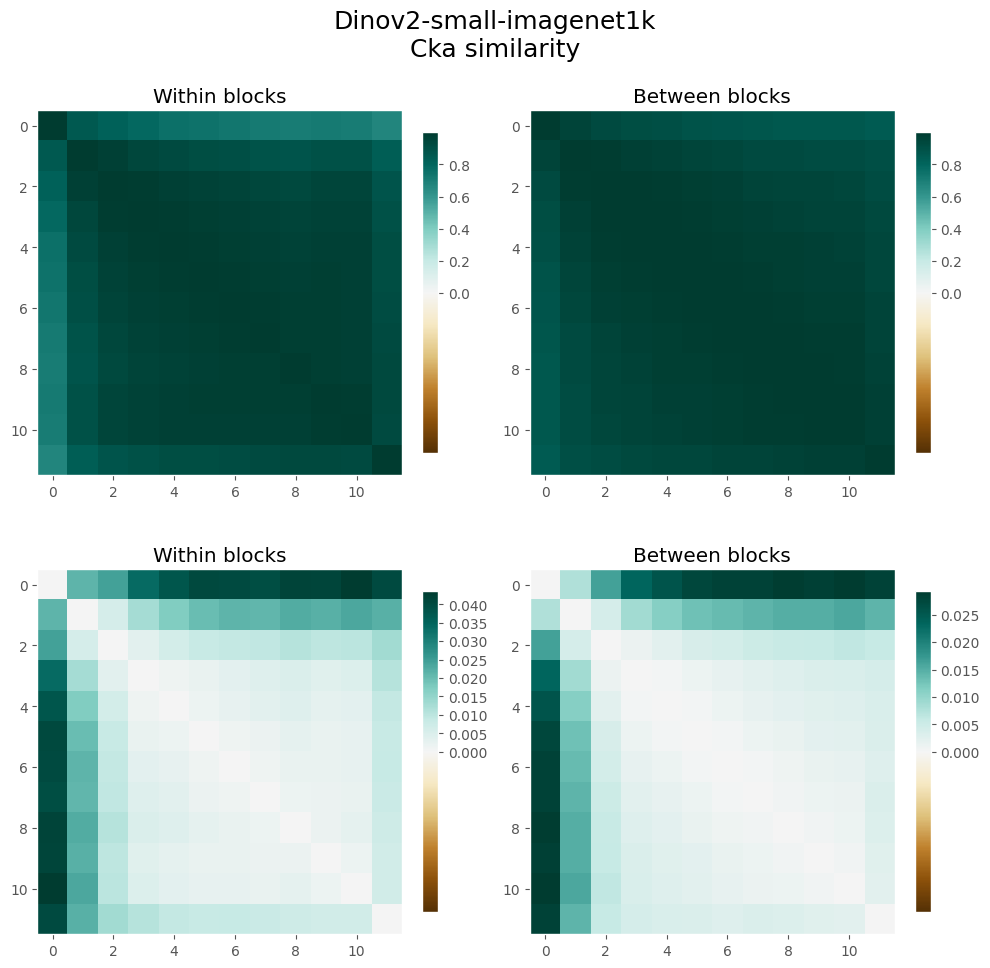

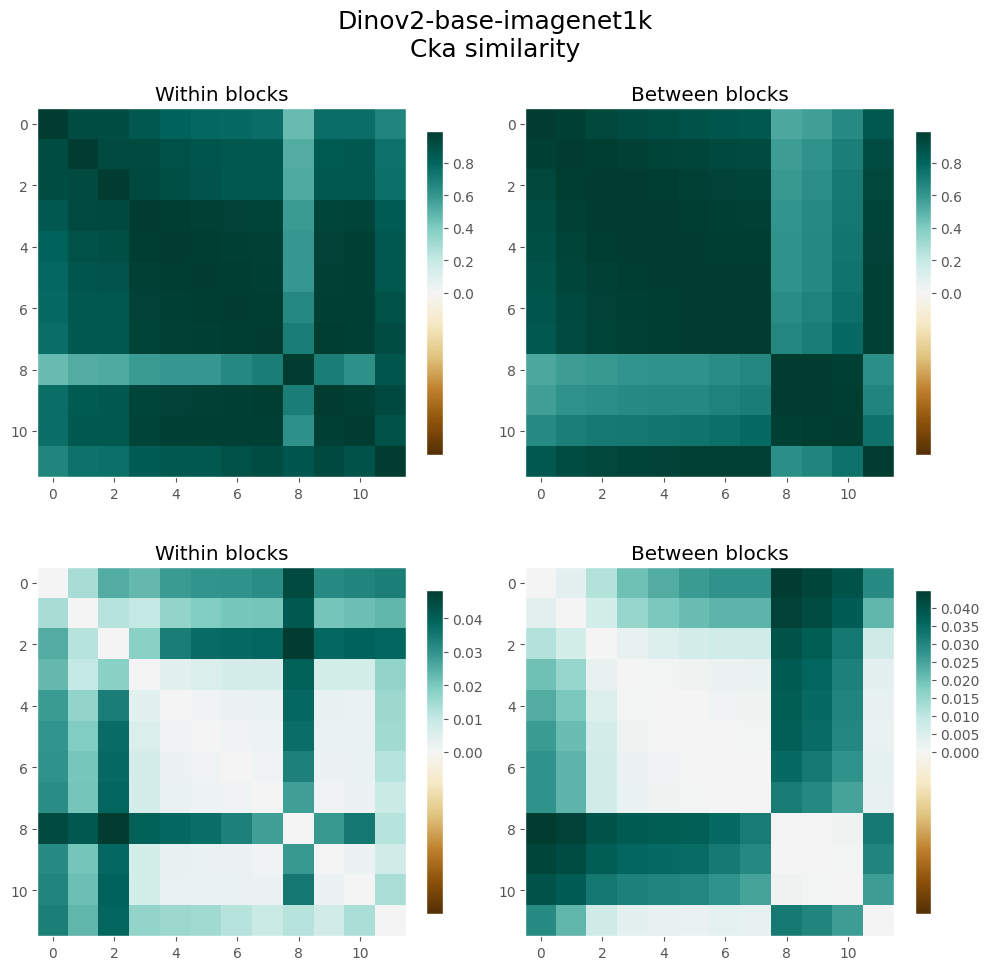

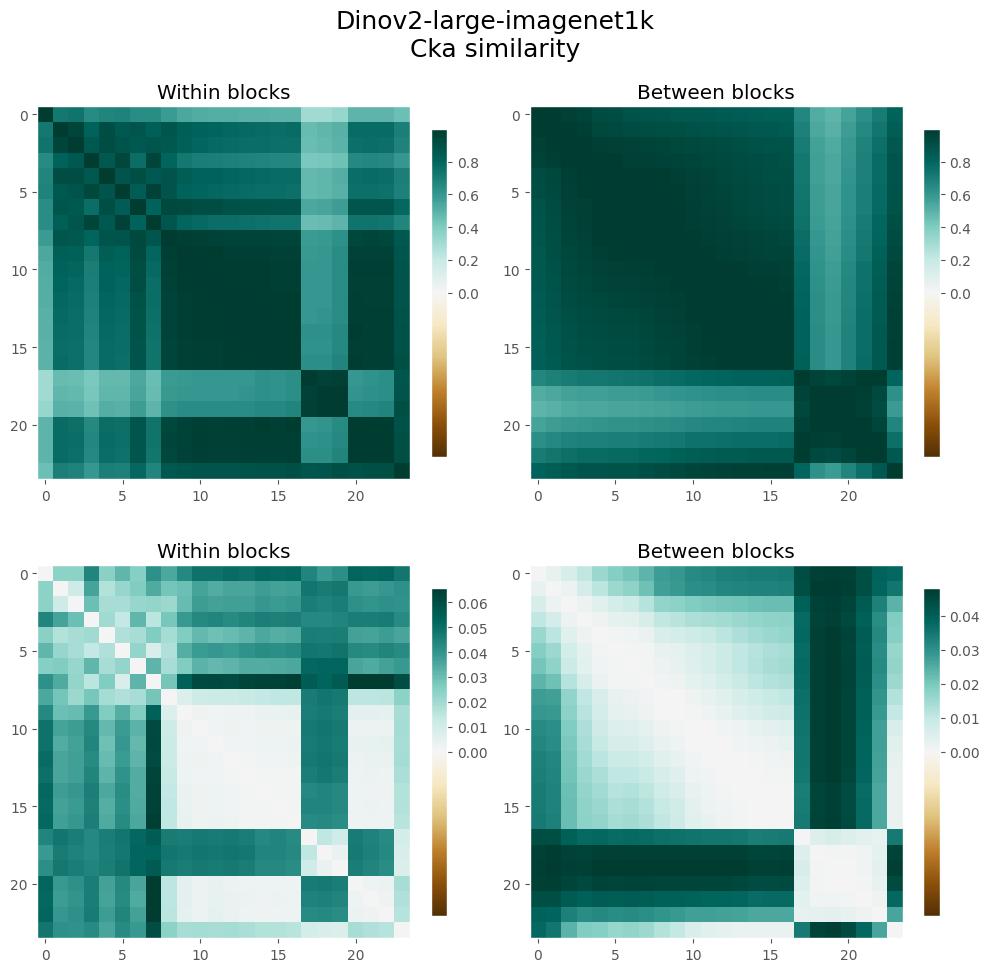

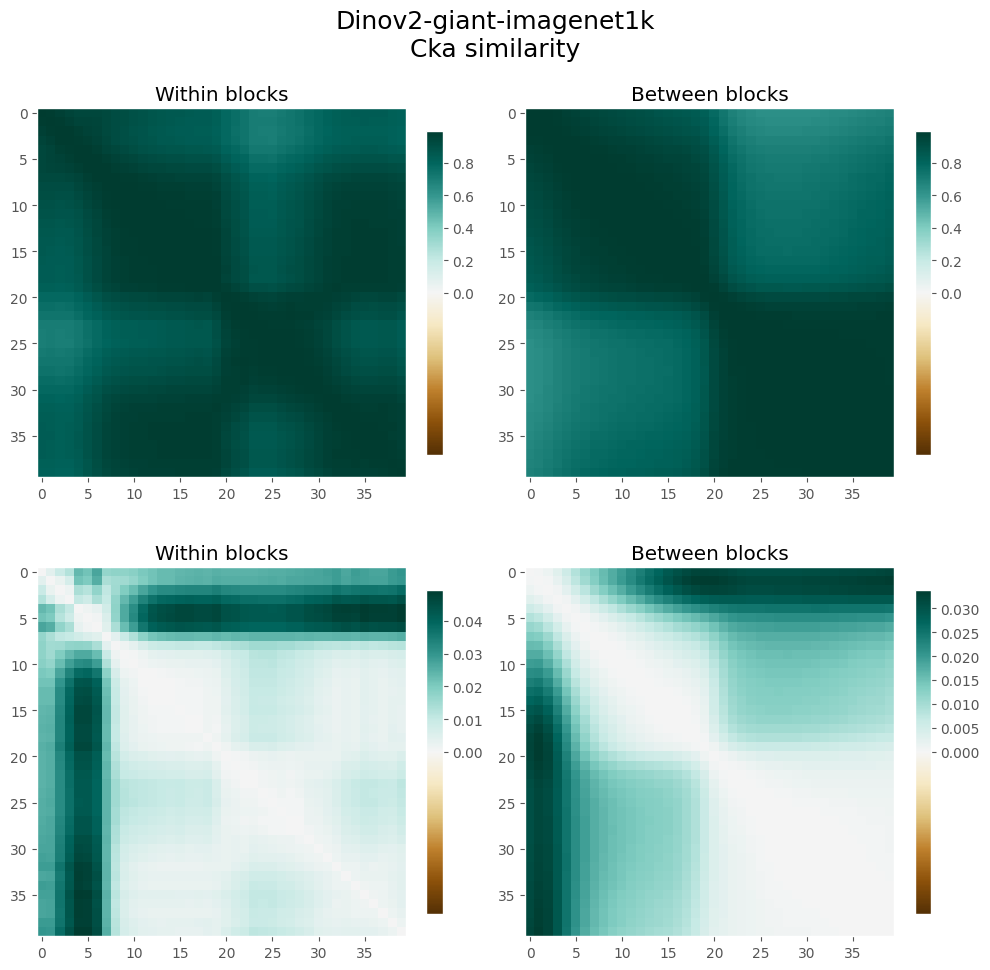

In [26]:
experiments = {
    'dinov2-small-imagenet1k': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=True_['cosine-similarity', 'cka-similarity']_start-iter=0_results.pth",
    'dinov2-base-imagenet1k': EXP_PATH / "vision/dinov2-base-imagenet1k-1-layer/within=True_['cosine-similarity', 'cka-similarity']_start-iter=0_results.pth",
    'dinov2-large-imagenet1k': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/within=True_['cosine-similarity', 'cka-similarity']_start-iter=0_results.pth",
    'dinov2-giant-imagenet1k': EXP_PATH / "vision/dinov2-giant-imagenet1k-1-layer/within=True_['cosine-similarity', 'cka-similarity']_start-iter=0_results.pth",
}
# Plot similarity matrices 
plot_similarity_matrices(experiments, types=['cka'])

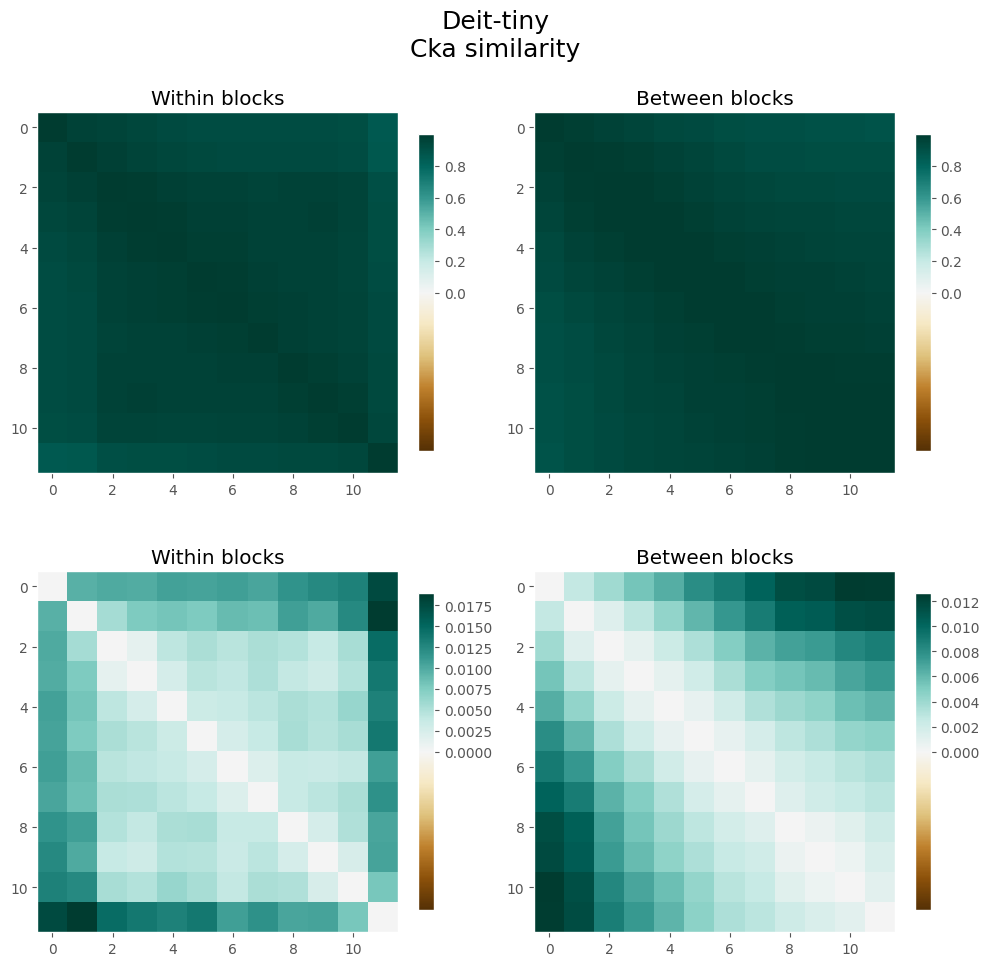

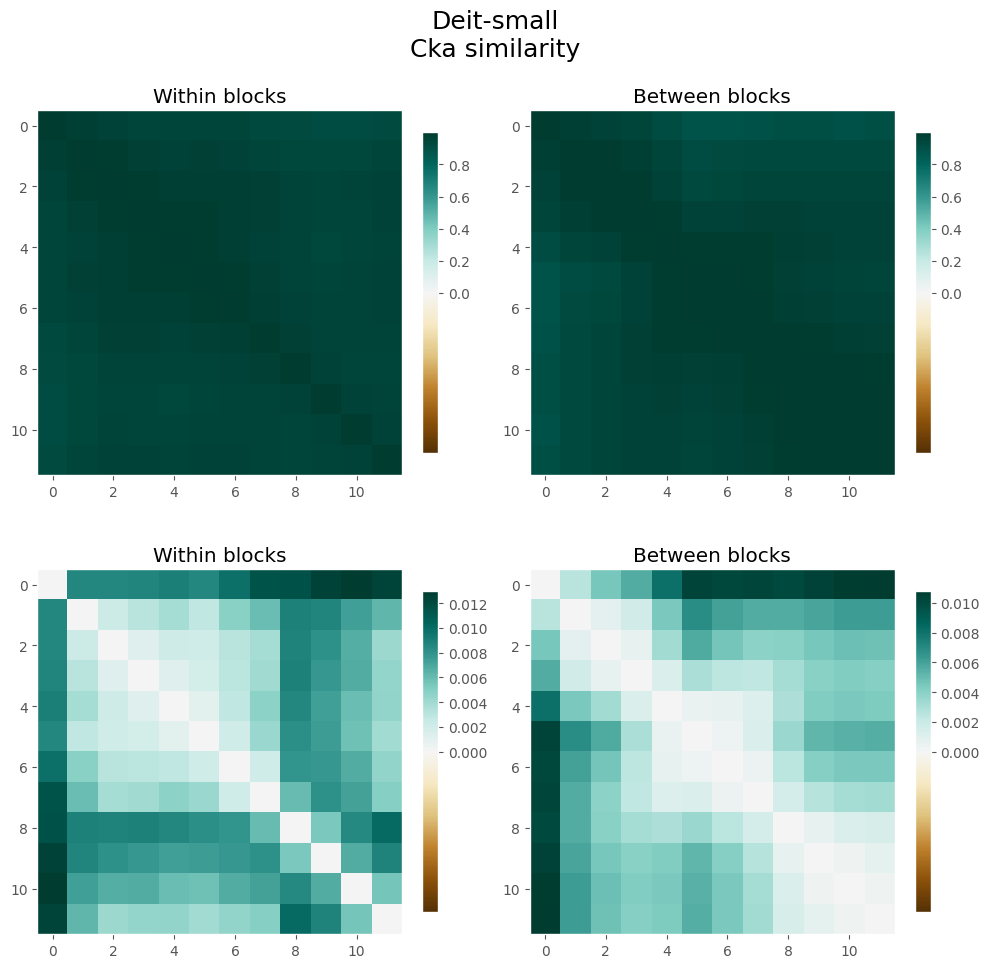

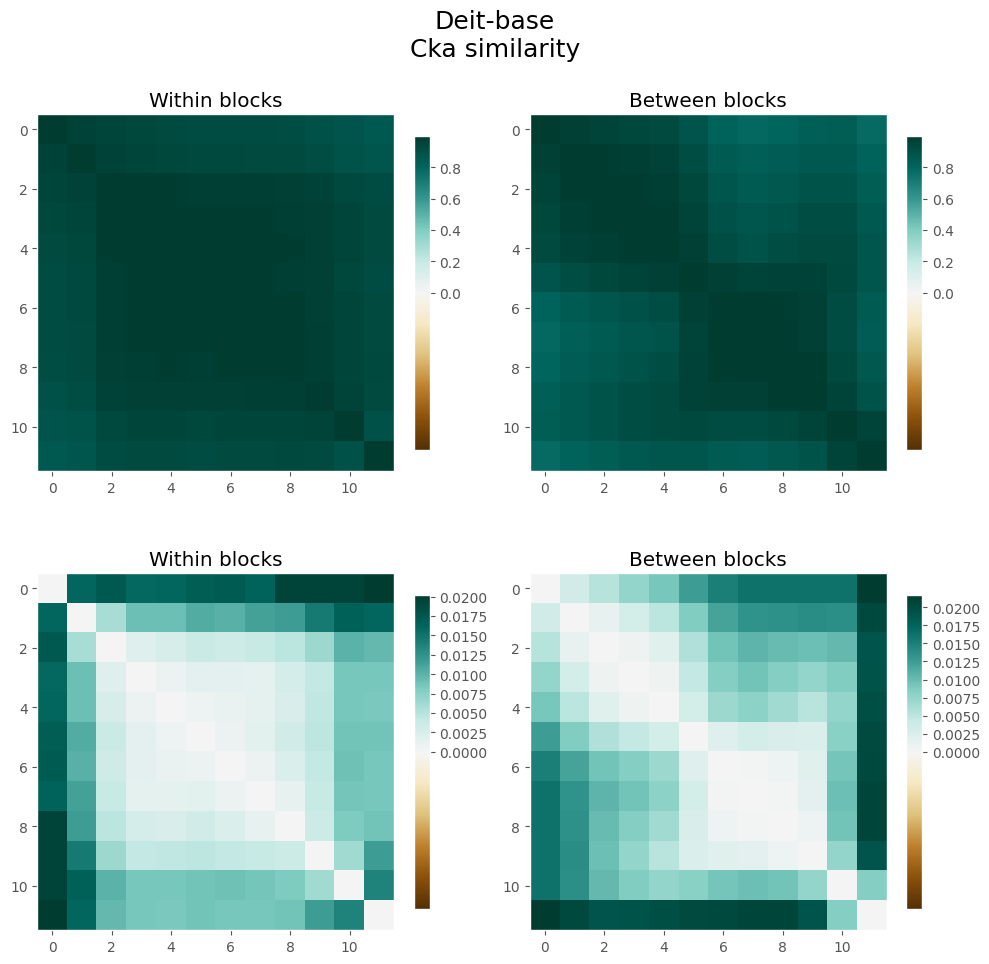

In [27]:
experiments = {
    'deit-tiny': EXP_PATH / "vision/deit-tiny/within=True_['cosine-similarity', 'cka-similarity']_start-iter=0_results.pth",
    'deit-small': EXP_PATH / "vision/deit-small/within=True_['cosine-similarity', 'cka-similarity']_start-iter=0_results.pth",
    'deit-base': EXP_PATH / "vision/deit-base/within=True_['cosine-similarity', 'cka-similarity']_start-iter=0_results.pth",
}
# Plot similarity matrices for large model
plot_similarity_matrices(experiments, types=['cka'])

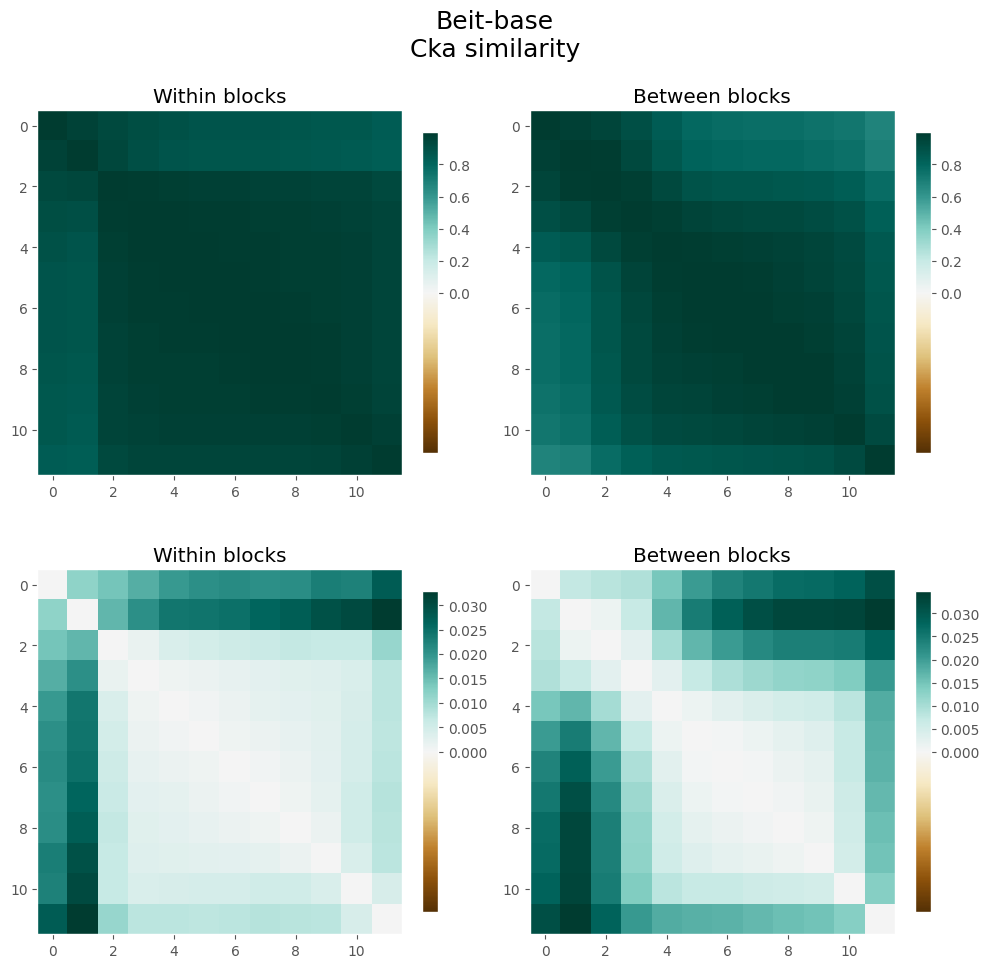

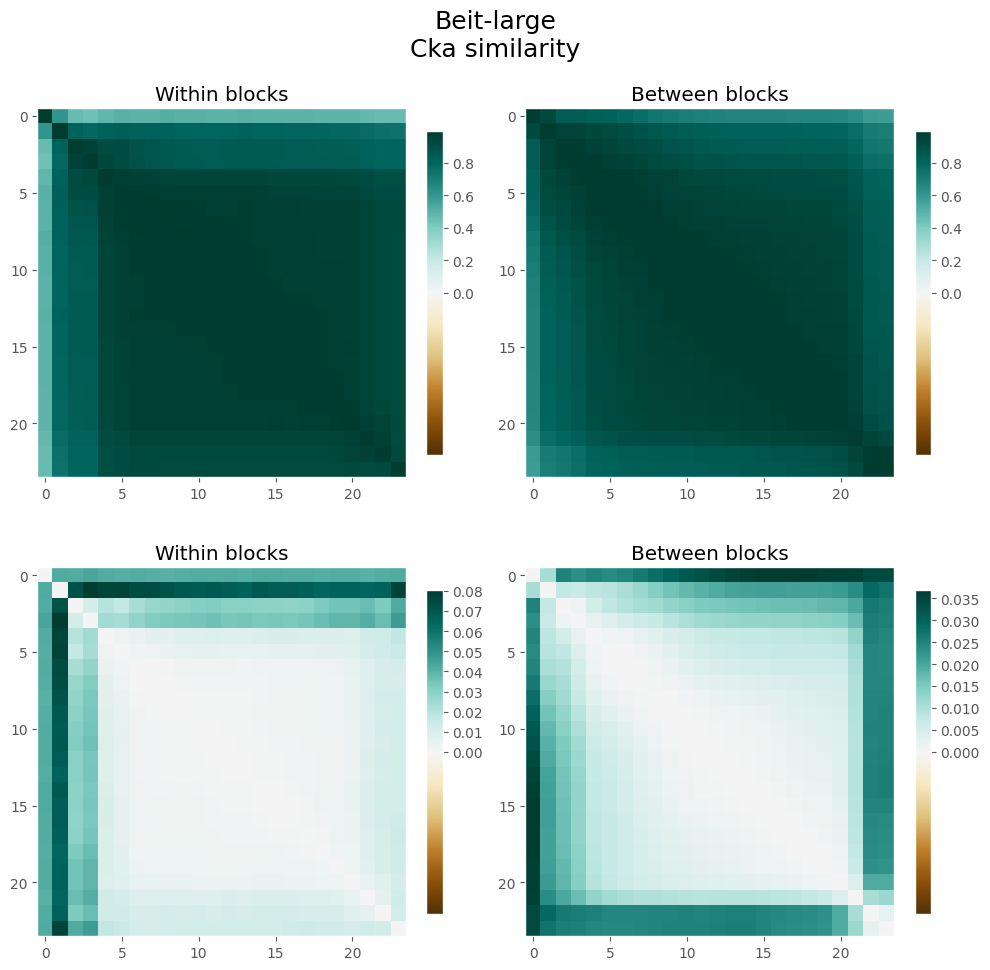

In [102]:
experiments = {
    'beit-base': EXP_PATH / "vision/beit-base/within=True_['cosine-similarity', 'cka-similarity']_start-iter=0_results.pth",
    'beit-large': EXP_PATH / "vision/beit-large/within=True_['cosine-similarity', 'cka-similarity']_start-iter=0_results.pth",
}
# Plot similarity matrices 
plot_similarity_matrices(experiments, types=['cka'])

## Block Inference scores (pruning)

In [3]:
import numpy as np

def plot_block_influence(experiments, ax, res_per_exp=1):
    assert res_per_exp <= 3
    color_idx = -1
    start_layer_idx = 2
    for exp_name, exp_path in experiments.items():
        results = torch.load(exp_path)
        if 'all-block-inferences' in results.keys():
            results['all-block-influences'] = results['all-block-inferences']
        
        bi_scores = torch.vstack(results['all-block-influences'])
        n_samples, n_layers = bi_scores.shape
        color_idx += 1
        
        xaxis = np.arange(n_layers) / n_layers
        ax.plot(xaxis, bi_scores.mean(dim=0), label=exp_name, linestyle='-' if color_idx % res_per_exp == 0 else '--' if color_idx % res_per_exp == 1 else '-.', color=f'C{color_idx // res_per_exp}')
        ax.fill_between(xaxis, bi_scores.quantile(0.05, dim=0), bi_scores.quantile(0.95, dim=0), alpha=0.3, color=f'C{color_idx // res_per_exp}')

    ax.set(xlabel='Relative layer index', ylabel='Block Influence score [$\mu$ and 90% CI]')
    ax.legend()
    return ax

In [4]:
def merge_results(experiments):
    for i, (exp_name, exp_path) in enumerate(experiments.items()):
        results = torch.load(exp_path)
        if i == 0:
            merged_results = results
        else:
            for k in merged_results['accuracy'].keys():
                for i in range(len(merged_results['accuracy'][k])):
                    try:
                        merged_results['accuracy'][k][i] += results['accuracy'][k][i]
                    except KeyError:
                        pass
                        
            merged_results['all-jacobian-batch-similarities'] += results['all-jacobian-batch-similarities']

    return merged_results

In [5]:
import numpy as np

def get_rank(experiments, merge: bool = False, ranks: dict = {}, batch_size=None):
    if merge:
        results = {list(experiments.keys())[0]: merge_results(experiments)}
    else:
        results = {exp_name: torch.load(exp_path) for exp_name, exp_path in experiments.items()}

    for exp_name, res in results.items():
        _batch_size = int(exp_name.split("-")[-1]) if batch_size == 'varying' else batch_size

        num_layers = len(res['all-jacobian-batch-similarities'][0])
        rel_eigvals = torch.zeros((len(res['all-jacobian-batch-similarities']), num_layers))
        for i, _batch_sim_output in enumerate(res['all-jacobian-batch-similarities']):
            for j, (k, _batch_sim_output) in enumerate(_batch_sim_output.items()):
                if batch_size is not None:
                    _batch_sim_output = _batch_sim_output[:_batch_size, :_batch_size]

                eigvals, _ = torch.linalg.eigh(_batch_sim_output)
                rel_eigvals[i, j] = eigvals.max() / sum(eigvals)
        
        ranks[exp_name] = rel_eigvals
    
    return ranks

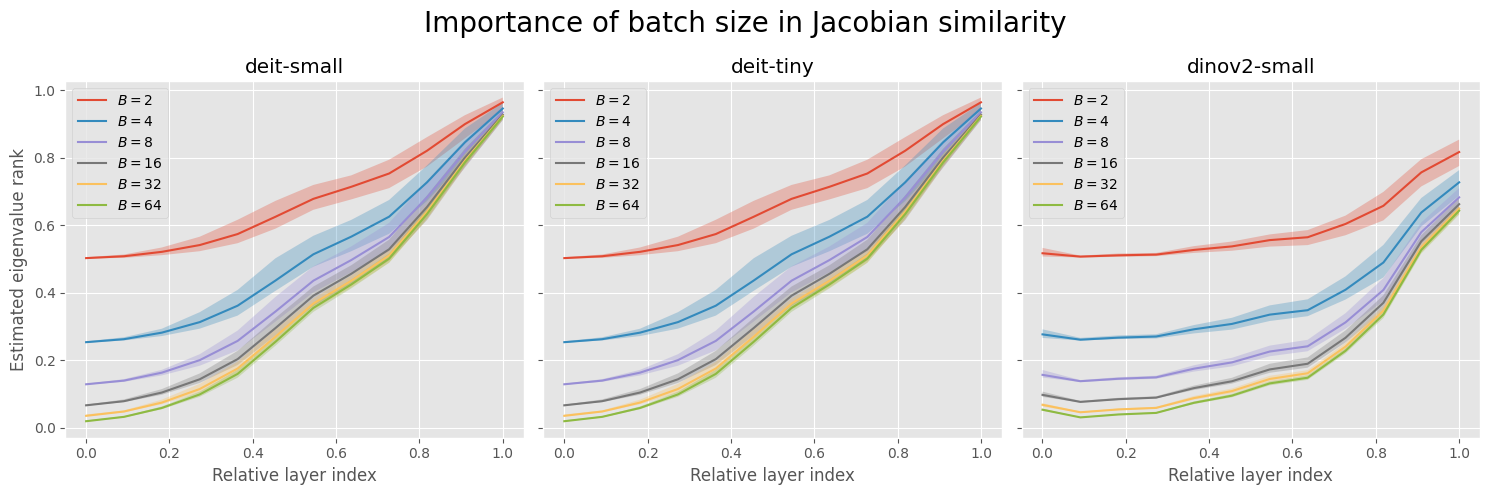

In [8]:

_experiments = [
    {
        'deit-small-2' : EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-small-4' : EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-small-8' : EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-small-16': EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-small-32': EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-small-64': EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    },
    {
        'deit-tiny-2' : EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-tiny-4' : EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-tiny-8' : EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-tiny-16': EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-tiny-32': EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-tiny-64': EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    },
    {
        'dinov2-small-2': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth",
        'dinov2-small-4': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth",
        'dinov2-small-8': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth",
        'dinov2-small-16': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth",
        'dinov2-small-32': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth",
        'dinov2-small-64': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth",
    }
]

fig, axs = plt.subplots(1, len(_experiments), figsize=(int(len(_experiments) * 5), 5), sharey=True)
for i, experiments in enumerate(_experiments):
    ranks = get_rank(experiments, merge=False, ranks={}, batch_size='varying')
    for exp_name, rel_eigvals in ranks.items():
        num_layers = rel_eigvals.shape[1]
        if len(_experiments) == 1:
            axs.plot(np.linspace(0, 1, num_layers), rel_eigvals.mean(dim=0), label=f"$B={exp_name.split('-')[-1]}$")
            axs.fill_between(np.linspace(0, 1, num_layers), rel_eigvals.quantile(0.05, dim=0), rel_eigvals.quantile(0.95, dim=0), alpha=0.3)    
        else:
            axs[i].plot(np.linspace(0, 1, num_layers), rel_eigvals.mean(dim=0), label=f"$B={exp_name.split('-')[-1]}$")
            axs[i].fill_between(np.linspace(0, 1, num_layers), rel_eigvals.quantile(0.05, dim=0), rel_eigvals.quantile(0.95, dim=0), alpha=0.3)    

    if len(_experiments) == 1:
        axs.set_xlabel('Relative layer index', fontsize=16)
        axs.legend()
    else:
        axs[i].set_xlabel('Relative layer index')
        axs[i].set_title("-".join(list(experiments.keys())[0].split("-")[:2]))
        axs[i].legend()

if len(_experiments) == 1:
    axs.set_ylabel('Estimated eigenvalue rank', fontsize=16)
else:
    axs[0].set_ylabel('Estimated eigenvalue rank')
    fig.suptitle('Importance of batch size in Jacobian similarity', fontsize=20)
    
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Eigenvalue rank for BEiT-base when Jacobian similarity to GT class')

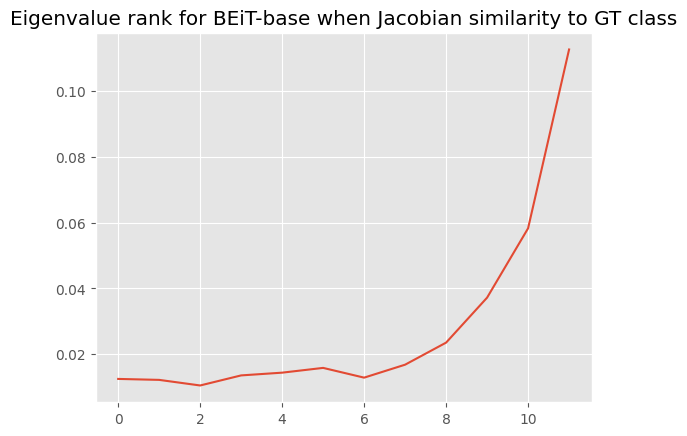

In [27]:
experiments = {
    'beit-base-new': r"C:\Users\alber\Desktop\DTU\4_HCAI\convexity\transformer_redundancy\single_target\vision\beit-base\within=False_['jacobian-similarity']_start-iter=0_results.pth",
}
ranks = get_rank(experiments, ranks={})
plt.plot(ranks['beit-base-new'].mean(dim=0))
plt.title('Eigenvalue rank for BEiT-base when Jacobian similarity to GT class')

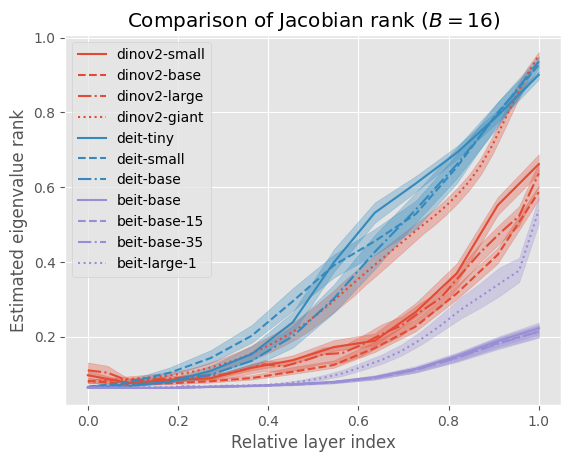

In [13]:
### DiNO
dino_experiments_small = {
    'dinov2-small': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth",
}
dino_experiments_base = {
    'dinov2-base': EXP_PATH / "vision/dinov2-base-imagenet1k-1-layer/iter0.pth",
    'dinov2-base-10': EXP_PATH / "vision/dinov2-base-imagenet1k-1-layer/iter10.pth",
    'dinov2-base-20': EXP_PATH / "vision/dinov2-base-imagenet1k-1-layer/iter20.pth",
    'dinov2-base-30': EXP_PATH / "vision/dinov2-base-imagenet1k-1-layer/iter30.pth",
    'dinov2-base-40': EXP_PATH / "vision/dinov2-base-imagenet1k-1-layer/iter40.pth",
}
dino_experiments_large = {
    'dinov2-large': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter0.pth",
    'dinov2-large-5': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter5.pth",
    'dinov2-large-10': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter10.pth",
    'dinov2-large-15': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter15.pth",
    'dinov2-large-20': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter20.pth",
    'dinov2-large-25': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter25.pth",
    'dinov2-large-30': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter30.pth",
    'dinov2-large-35': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter35.pth",
    'dinov2-large-40': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter40.pth",
    'dinov2-large-45': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter45.pth",
}
dino_experiments_giant = {
    'dinov2-giant': EXP_PATH / "vision/dinov2-giant-imagenet1k-1-layer/iter0.pth",
}
dino_experiments_giant.update({
    f'dinov2-giant-{i}': EXP_PATH / f"vision/dinov2-giant-imagenet1k-1-layer/iter{i}.pth" for i in range(1, 48)
})

ranks = get_rank(dino_experiments_small, ranks={}, batch_size=16)
ranks = get_rank(dino_experiments_base, merge=True, ranks=ranks, batch_size=16)
ranks = get_rank(dino_experiments_large, merge=True, ranks=ranks, batch_size=16)
ranks = get_rank(dino_experiments_giant, merge=True, ranks=ranks, batch_size=16)

### DEIT
deit_experiments = {
    'deit-tiny': EXP_PATH / "vision/deit-tiny/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    'deit-small': EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
}
deit_experiments_base = {
    'deit-base': EXP_PATH / "vision/deit-base/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    'deit-base-20': EXP_PATH / "vision/deit-base/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=20_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    'deit-base-40': EXP_PATH / "vision/deit-base/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=40_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
}
ranks = get_rank(deit_experiments, ranks=ranks, batch_size=16)
ranks = get_rank(deit_experiments_base, ranks=ranks, merge=True, batch_size=16)

# BEIT
beit_experiments_base = {
    'beit-base': EXP_PATH / "vision/beit-base/iter0.pth",
    'beit-base-15': EXP_PATH / "vision/beit-base/iter15.pth",
    'beit-base-35': EXP_PATH / "vision/beit-base/iter35.pth",
}
beit_experiments_large = {
    # 'beit-large': EXP_PATH / "vision/beit-large/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    'beit-large-1': EXP_PATH / "vision/beit-large/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=1_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    'beit-large-10': EXP_PATH / "vision/beit-large/iter10.pth",
    'beit-large-20': EXP_PATH / "vision/beit-large/iter20.pth",
    'beit-large-30': EXP_PATH / "vision/beit-large/iter30.pth",
    'beit-large-40': EXP_PATH / "vision/beit-large/iter40.pth",
}
ranks = get_rank(beit_experiments_base, ranks=ranks, batch_size=16)
ranks = get_rank(beit_experiments_large, ranks=ranks, merge=True, batch_size=16)

previous_exp = ''
color_idx = -1
linestyle_idx = 0
linestyles = ['-', '--', '-.', ':']

for exp_name, rel_eigvals in ranks.items():
    if exp_name.split("-")[0] in previous_exp:
        linestyle_idx += 1
    else:
        color_idx += 1
        linestyle_idx = 0

    num_layers = rel_eigvals.shape[1]
    plt.plot(np.linspace(0, 1, num_layers), rel_eigvals.mean(dim=0), label=exp_name, color=f'C{color_idx}', linestyle=linestyles[linestyle_idx])
    plt.fill_between(np.linspace(0, 1, num_layers), rel_eigvals.quantile(0.025, dim=0), rel_eigvals.quantile(0.975, dim=0), alpha=0.3, color=f'C{color_idx}')    
    
    previous_exp = exp_name

plt.xlabel('Relative layer index')
plt.ylabel('Estimated eigenvalue rank')
plt.legend()
plt.title('Comparison of Jacobian rank ($B=16$)')
plt.show()

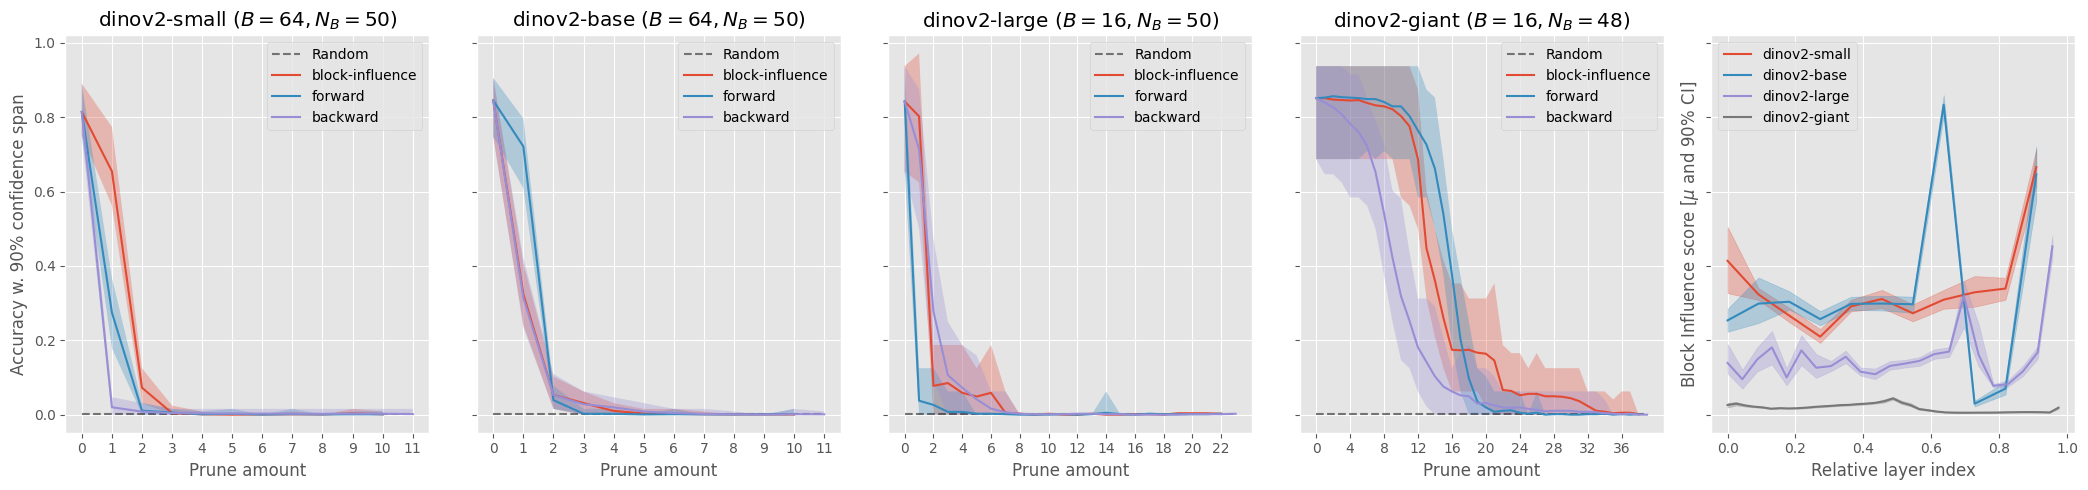

In [35]:
all_results = {
    'dinov2-small': torch.load(EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth"),
    'dinov2-base': merge_results(dino_experiments_base),
    'dinov2-large': merge_results(dino_experiments_large),
    'dinov2-giant': merge_results(dino_experiments_giant),
}

num_classes = 1000
_conf = 90
_alpha = round((1 - _conf / 100), 2)

fig, axs = plt.subplots(1, len(all_results.keys()) + 1, figsize=(int(5*len(all_results.keys()) + 1), 5), sharey=True)
for i, (exp_name, results) in enumerate(all_results.items()):
    n_batches = results['all-jacobian-batch-similarities'].__len__()
    batch_size = results['all-block-influences'][0].shape[0]
    num_layers = results['all-block-influences'][0].shape[1] + 1

    axs[i].hlines(1/num_classes, xmin=0, xmax=num_layers-1, color='black', linestyle='--', alpha=0.5, label='Random')
    for pruning_strategy in ['block-influence', 'forward', 'backward']:
        mean_accs = {k: torch.tensor(v).mean().item() for k, v in results['accuracy'][pruning_strategy].items()}
        lower_accs = {k: torch.tensor(v).quantile(_alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}
        upper_accs = {k: torch.tensor(v).quantile(1 - _alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}
        axs[i].fill_between(mean_accs.keys(), list(lower_accs.values()), list(upper_accs.values()), alpha=0.3)
        axs[i].plot(mean_accs.keys(), list(mean_accs.values()), label=pruning_strategy)

    # axs[i].set_xlim(0, 8)
    axs[i].legend()
    axs[i].set(xlabel='Prune amount', title=f'{exp_name} ($B = {batch_size}, N_B = {n_batches}$)')
    axs[i].set_xticks(range(num_layers)[::num_layers // 10], range(num_layers)[::num_layers // 10])
axs[0].set(ylabel=f'Accuracy w. {_conf}% confidence span')

# Plot block influence scores
experiments = {
    'dinov2-small': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth",
    'dinov2-base': EXP_PATH / "vision/dinov2-base-imagenet1k-1-layer/iter0.pth",
    'dinov2-large': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter0.pth",
    'dinov2-giant': EXP_PATH / "vision/dinov2-giant-imagenet1k-1-layer/iter0.pth",
}

plot_block_influence(experiments, axs[i+1], res_per_exp=1)
axs[i+1].set_title('')
plt.tight_layout()
plt.show()

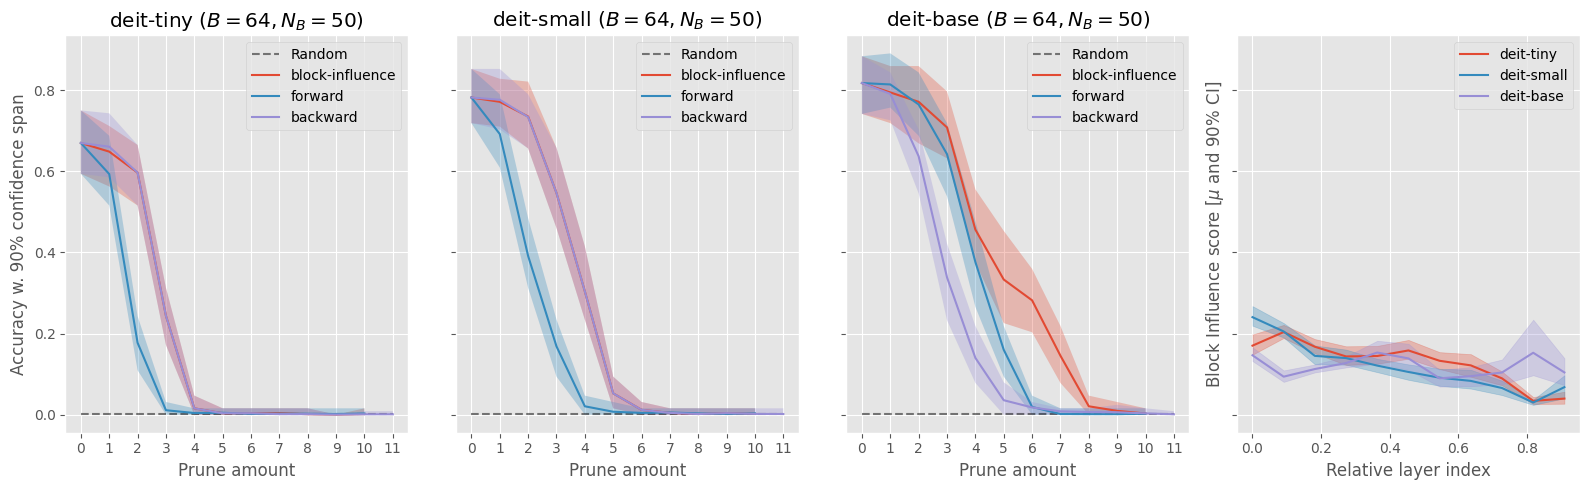

In [30]:
all_results = {
    'deit-tiny': torch.load(EXP_PATH / "vision/deit-tiny/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth"),
    'deit-small': torch.load(EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth"),
    'deit-base': merge_results(deit_experiments_base),
}

num_classes = 1000
_conf = 90
_alpha = round((1 - _conf / 100), 2)

fig, axs = plt.subplots(1, len(all_results.keys()) + 1, figsize=(int(5*len(all_results.keys()) + 1), 5), sharey=True)
for i, (exp_name, results) in enumerate(all_results.items()):
    n_batches = results['all-jacobian-batch-similarities'].__len__()
    batch_size = results['all-block-influences'][0].shape[0]
    num_layers = results['all-block-influences'][0].shape[1] + 1

    axs[i].hlines(1/num_classes, xmin=0, xmax=num_layers-1, color='black', linestyle='--', alpha=0.5, label='Random')
    for pruning_strategy in ['block-influence', 'forward', 'backward']:
        mean_accs = {k: torch.tensor(v).mean().item() for k, v in results['accuracy'][pruning_strategy].items()}
        lower_accs = {k: torch.tensor(v).quantile(_alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}
        upper_accs = {k: torch.tensor(v).quantile(1 - _alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}
        axs[i].fill_between(mean_accs.keys(), list(lower_accs.values()), list(upper_accs.values()), alpha=0.3)
        axs[i].plot(mean_accs.keys(), list(mean_accs.values()), label=pruning_strategy)

    # axs[i].set_xlim(0, 8)
    axs[i].legend()
    axs[i].set(xlabel='Prune amount', title=f'{exp_name} ($B = {batch_size}, N_B = {n_batches}$)')
    axs[i].set_xticks(range(num_layers)[::num_layers // 10], range(num_layers)[::num_layers // 10])
axs[0].set(ylabel=f'Accuracy w. {_conf}% confidence span')

# Plot block influence scores
experiments = {
    'deit-tiny': EXP_PATH / "vision/deit-tiny/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    'deit-small': EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    'deit-base': EXP_PATH / "vision/deit-base/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
}

plot_block_influence(experiments, axs[i+1], res_per_exp=1)
axs[i+1].set_title('')
plt.tight_layout()
plt.show()

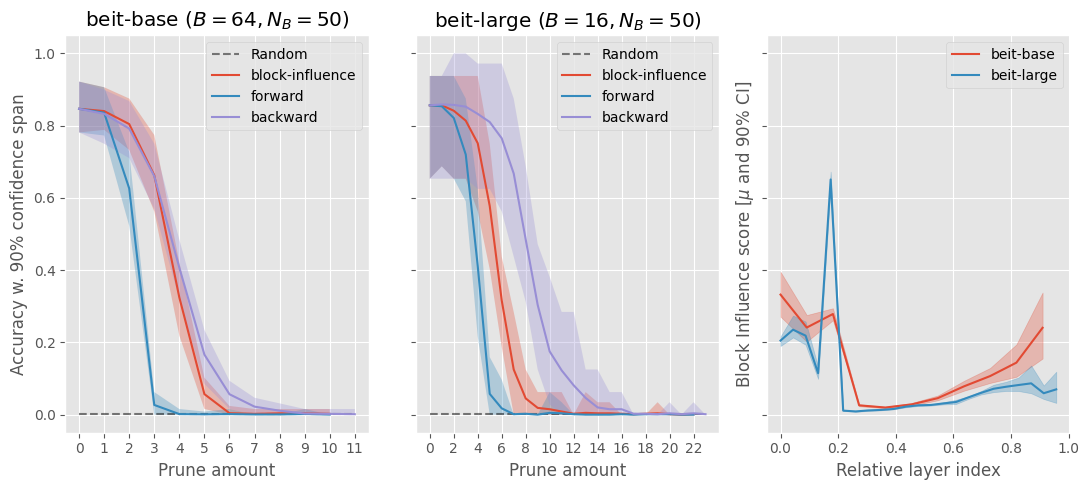

In [29]:
all_results = {
    'beit-base': merge_results(beit_experiments_base),
    'beit-large': merge_results(beit_experiments_large),
}

num_classes = 1000
_conf = 90
_alpha = round((1 - _conf / 100), 2)

fig, axs = plt.subplots(1, len(all_results.keys()) + 1, figsize=(int(5*len(all_results.keys()) + 1), 5), sharey=True)
for i, (exp_name, results) in enumerate(all_results.items()):
    n_batches = results['all-jacobian-batch-similarities'].__len__()
    batch_size = results['all-block-influences'][0].shape[0]
    num_layers = results['all-block-influences'][0].shape[1] + 1

    axs[i].hlines(1/num_classes, xmin=0, xmax=num_layers-1, color='black', linestyle='--', alpha=0.5, label='Random')
    for pruning_strategy in ['block-influence', 'forward', 'backward']:
        mean_accs = {k: torch.tensor(v).mean().item() for k, v in results['accuracy'][pruning_strategy].items()}
        lower_accs = {k: torch.tensor(v).quantile(_alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}
        upper_accs = {k: torch.tensor(v).quantile(1 - _alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}
        axs[i].fill_between(mean_accs.keys(), list(lower_accs.values()), list(upper_accs.values()), alpha=0.3)
        axs[i].plot(mean_accs.keys(), list(mean_accs.values()), label=pruning_strategy)

    # axs[i].set_xlim(0, 8)
    axs[i].legend()
    axs[i].set(xlabel='Prune amount', title=f'{exp_name} ($B = {batch_size}, N_B = {n_batches}$)')
    axs[i].set_xticks(range(num_layers)[::num_layers // 10], range(num_layers)[::num_layers // 10])
axs[0].set(ylabel=f'Accuracy w. {_conf}% confidence span')

# Plot block influence scores
experiments = {
    'beit-base': EXP_PATH / "vision/beit-base/iter0.pth",
    'beit-large': EXP_PATH / "vision/beit-large/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
}

plot_block_influence(experiments, axs[i+1], res_per_exp=1)
axs[i+1].set_title('')
plt.tight_layout()
plt.show()

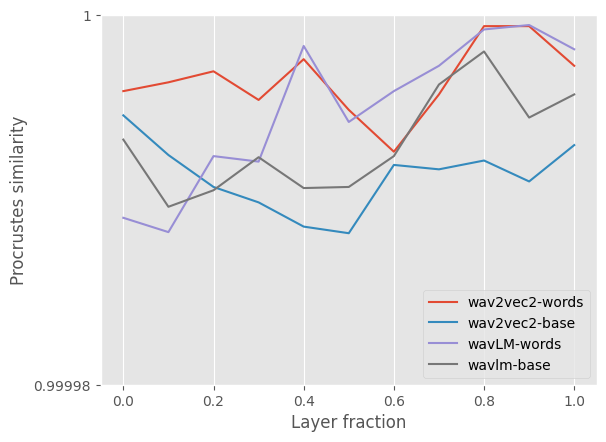

In [36]:
experiments = {
    'wav2vec2-words': EXP_PATH / "audio/wav2vec2-words/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'wav2vec2-base': EXP_PATH / "audio/wav2vec2-base/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'wavLM-words': EXP_PATH / "audio/wavLM-words/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'wavlm-base': EXP_PATH / "audio/wavlm-base/within=True_['procrustes-similarity']_start-iter=0_results.pth",
}

for exp_name, exp_path in experiments.items():
    sims = torch.load(exp_path)
    sims = torch.tensor([sims['all-procrustes-similarities'][i]['between'] for i in range(50)])

    xaxis = torch.linspace(0, 1, len(sims.mean(dim=0)))
    plt.plot(xaxis, sims.mean(dim=0), label=exp_name)
    # plt.fill_between(xaxis, sims.quantile(dim=0, q=0.05), sims.quantile(dim=0, q=0.95), alpha=0.2)
    plt.xlabel('Layer fraction')
    plt.ylabel('Procrustes similarity')

plt.ylim(0.99998, 1)
plt.yticks([0.99998, 1], [0.99998, 1])
plt.legend(loc='lower right')
plt.show()

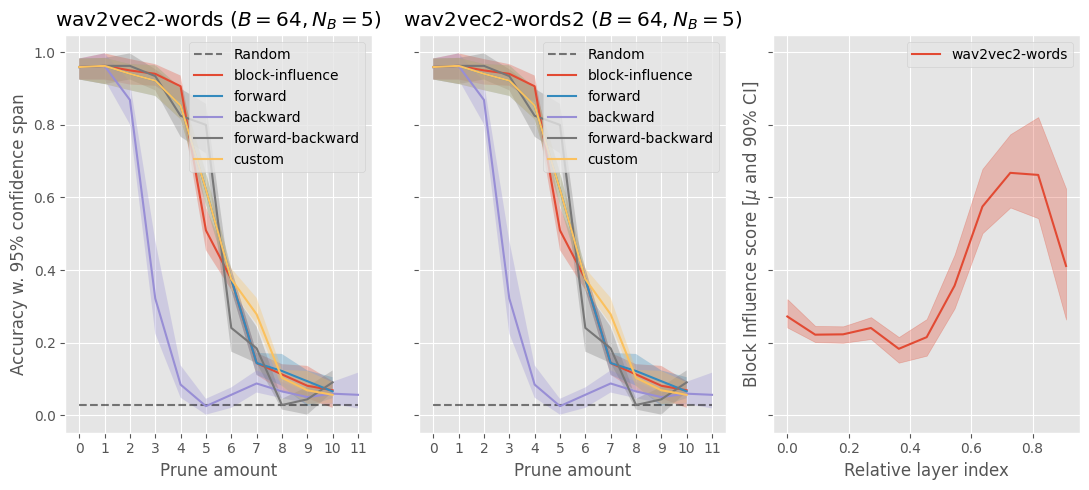

In [15]:
num_classes = 35

all_results = {
    'wav2vec2-words': torch.load(EXP_PATH / "audio/wav2vec2-words/within=False_['pruning-performance']_start-iter=0_pruned-by=['forward-backward', 'forward', 'backward', 'block-influence']_results.pth"),
    'wav2vec2-words2': torch.load(EXP_PATH / "audio/wav2vec2-words/within=False_['pruning-performance']_start-iter=0_pruned-by=['forward-backward', 'forward', 'backward', 'block-influence']_results.pth"),
}

fig, axs = plt.subplots(1, len(all_results.keys()) + 1, figsize=(int(5*len(all_results.keys()) + 1), 5), sharey=True)
for i, (exp_name, results) in enumerate(all_results.items()):
    n_batches = results['accuracy']['forward'][0].__len__()
    batch_size = results['all-block-influences'][0].shape[0]
    num_layers = results['all-block-influences'][0].shape[1] + 1

    axs[i].hlines(1/num_classes, xmin=0, xmax=num_layers-1, color='black', linestyle='--', alpha=0.5, label='Random')
    for pruning_strategy in ['block-influence', 'forward', 'backward', 'forward-backward', 'custom']:
        mean_accs = {k: torch.tensor(v).mean().item() for k, v in results['accuracy'][pruning_strategy].items()}
        lower_accs = {k: torch.tensor(v).quantile(0.025).item() for k, v in results['accuracy'][pruning_strategy].items()}
        upper_accs = {k: torch.tensor(v).quantile(0.975).item() for k, v in results['accuracy'][pruning_strategy].items()}
        axs[i].fill_between(mean_accs.keys(), list(lower_accs.values()), list(upper_accs.values()), alpha=0.3)
        axs[i].plot(mean_accs.keys(), list(mean_accs.values()), label=pruning_strategy)

    # axs[i].set_xlim(0, 8)
    axs[i].legend()
    axs[i].set(xlabel='Prune amount', title=f'{exp_name} ($B = {batch_size}, N_B = {n_batches}$)')
    axs[i].set_xticks(range(num_layers)[::num_layers // 10], range(num_layers)[::num_layers // 10])
axs[0].set(ylabel='Accuracy w. 95% confidence span')

# Plot block influence scores
experiments = {
    'wav2vec2-words': EXP_PATH / "audio/wav2vec2-words/within=False_['pruning-performance']_start-iter=0_pruned-by=['forward-backward', 'forward', 'backward', 'block-influence']_results.pth",
}

plot_block_influence(experiments, axs[i+1], res_per_exp=1)
axs[i+1].set_title('')
plt.tight_layout()
plt.show()